In [1]:
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import torch
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Initial Setup

Specify the RUN_ID, whether you want to save the models after running the optimization. The reference values are specified in `ref_values.csv` file for each run_id. The ref values are updated after data for $s$ has been imported. 

The ref values ensure a reasonable range for the SR. The inputs $(i,d,SOC,s)$ are scaled to be between 0,1. 

In [3]:
RUN_ID = 'test3'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e1)

REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

LATEX_DICT = SR_lib.get_latex_dict()

VARIABLES = ['R0','R1', 'C1', 'k', 'sdot', 'Ue']
# Optimization settings for PySR
SELECTION = "best"

if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')


## Load the NN model and extract samples

The sample points are obtained by running the `lhs_SR.py` file and saving the values to a .csv file. 

The samples are plotted here to verify the sampling. 

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using Q0_ckpt = 17921.57581, I_ref = 24.89107751102174 and u_ref = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


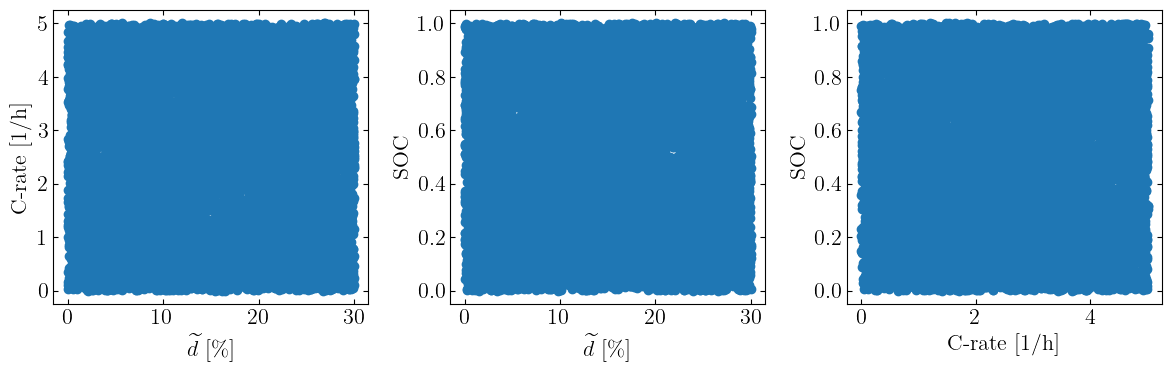

In [4]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('SR_samples.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('../data/polished_combo/combo_half.txt', delimiter=';')

f, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[0].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[0].set_ylabel('C-rate [1/h]')
ax[1].set_xlabel('C-rate [1/h]')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[1].set_xlabel(r'$\widetilde{d}$ [\%]')
ax[1].set_ylabel('SOC ')
ax[2].plot(df['C_rate'],df['SOC'], 'o')
ax[2].set_xlabel('C-rate [1/h]')
ax[2].set_ylabel('SOC ')
plt.tight_layout()

## Loading data for $s$



In [5]:
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)
s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)

s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']].copy()
REF_VALUES['s'] = s_data['s'].max()

s_data['C'] = s_data['I'] * 3600 / Q0


s_data['s'] = s_data['s'] / REF_VALUES['s']

s_data['C'] = s_data['C'] / REF_VALUES['C']

s_data['u_per'] = s_data['u_per'] / REF_VALUES['d']

s_data['sdot'] = s_data['sdot'] / REF_VALUES['sdot']
s_data.describe()



,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.294561,0.869936,0.279603
std,6.807070,0.309418,0.257924,0.240674,1.009850,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.003351,0.000000
25%,0.000000,0.176667,0.329973,0.093446,0.087223,0.000000
50%,4.480394,0.406667,0.548750,0.227796,0.599727,0.180000
75%,10.952074,0.686667,0.762836,0.459088,1.125820,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.313158,1.000000


### Save the reference value for $s$

In [6]:
# Save reference values for simulating the observed outputs. 

save_refvalues = True
if save_refvalues:
    df_ref = pd.DataFrame(REF_VALUES, index=[0])
    df_existing = pd.read_csv("saved_sr_models/ref_values.csv")
    if RUN_ID in df_existing['run_id'].values:
        print(f'Run ID {RUN_ID} already exists in ref_values.csv. Did not save new reference values.')
    else:
        df_ref.to_csv(f'saved_sr_models/ref_values_{RUN_ID}.csv', index=False)
        df_ref['run_id'] = RUN_ID
        df_new = pd.DataFrame(df_ref, columns=df_existing.columns.values)
        df_combined = pd.concat([df_existing,df_new], ignore_index=True)
        df_combined.to_csv("saved_sr_models/ref_values.csv", index=False)

        #df_combined.to_excel("exp_log/Euler_exps.xlsx", index=False)

## Defining functions for computing the elements

In [7]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


### Generating samples and displaying the df for $R_0$, $R_1$, $C_1$ and $k$

In [8]:
samples = generate_data(df.values)
VARIABLES = ['R0','R1', 'C1', 'k']
N_VAR = len(VARIABLES)
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['d']
data['C'] =  data['C'] / REF_VALUES['C']
data.describe() 

  1%|          | 91/10000 [00:00<00:11, 892.64it/s]

100%|██████████| 10000/10000 [00:08<00:00, 1111.41it/s]


,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


### Visual overview of the scaled values

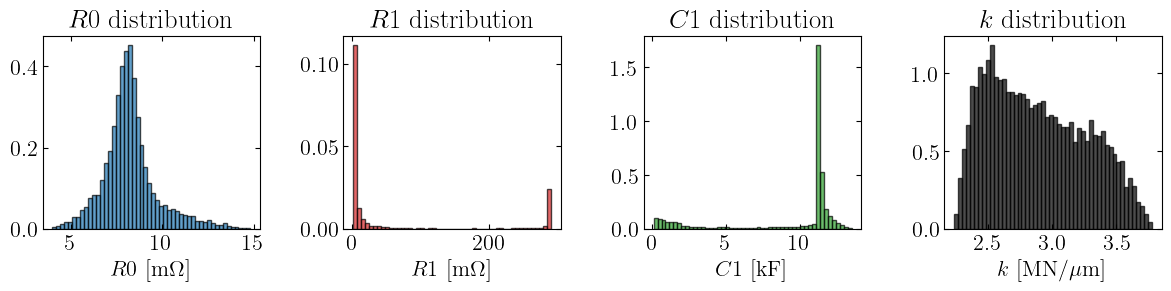

In [9]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var]*UNIT_CONV[var]*REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [10]:
def get_XY(d_frame, s_frame = None):
    '''Get input and output arrays for symbolic regression. If s_frame is provided, also return sdot values and corresponding inputs.'''

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values 
    Y_R1 = d_frame['R1'].values 
    Y_C1 = d_frame['C1'].values 
    Y_k  = d_frame['k'].values  
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

### Get training and test data 

In this case, the test data is not used. So the split is neglected. 

In [11]:
split_train = int(len(data) * 0.8)
s_split_train = int(len(s_data) * 0.8)

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]


X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    'sdot':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    'sdot':  Ys_test
}



# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_test3...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280976
Equation: 0.82365674

Model 1: Complexity=3, Loss=0.021061784
Equation: sqrt(sqrt(soc))

Model 2: Complexity=4, Loss=0.0149950655
Equation: soc ^ soc

Model 3: Complexity=5, Loss=0.009340014
Equation: sqrt(cube(soc) + 0.48839703)

Model 4: Complexity=6, Loss=0.006565835
Equation: sqrt(square(cube(soc)) + 0.55238205)

Model 5: Complexity=10, Loss=0.0059717693
Equation: sqrt((cube(soc) + 0.5771306) / (1.638934 ^ C))

Model 6: Complexity=11, Loss=0.0037985505
Equation: sqrt((0.7095664 / (1.638934 ^ C)) + cube(square(soc)))

Model 7: Complexity=12, Loss=0.0027787166
Equation: sqrt((0.63418955 / (exp(d) ^ C)) + square(square(soc)))

Model 8: Complexity=13, Loss=0.0024684356
Equation: sqrt((0.73008007 / (exp(d) ^ C)) + square(square(square(soc))))

Model 9: Complexity=15, Loss=0.0024271184
Equation: sqrt((0.7095664 / (exp(d) ^ C)) + square(square(square(soc)))) - -0.01362928

Model 10: Complexity=17, Loss=0.0023015758
Equation: sqrt(sqrt(exp(((d + C) *

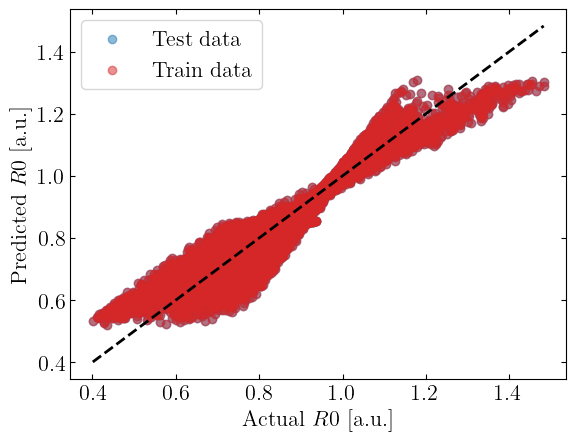

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(soc**8 + 0.73008007/exp(d)**C)
Loss: 0.0024684356
Best model complexity: 13


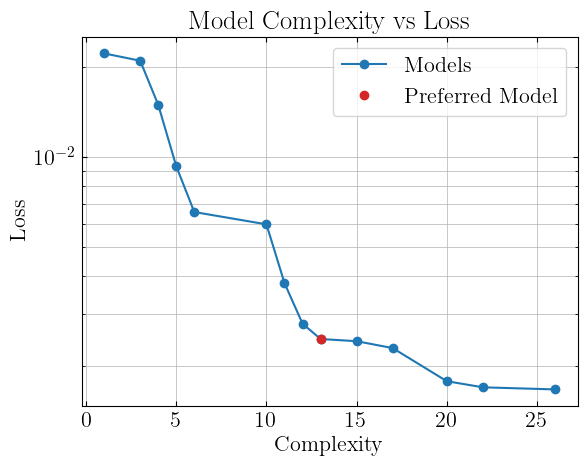

In [12]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_test3...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.21217
Equation: 5.67146

Model 1: Complexity=3, Loss=97.5087
Equation: C * 10.9234915

Model 2: Complexity=4, Loss=71.983665
Equation: cube(2.3547745 - soc)

Model 3: Complexity=5, Loss=51.59138
Equation: cube(exp(1.0961878 - soc))

Model 4: Complexity=6, Loss=40.193745
Equation: exp(cube(2.5205212 - exp(soc)))

Model 5: Complexity=7, Loss=38.266594
Equation: cube(exp(1.5909431 - soc) + -1.7918686)

Model 6: Complexity=8, Loss=26.497107
Equation: exp(((0.5526458 - soc) * 5.152091) + C)

Model 7: Complexity=9, Loss=25.8479
Equation: cube(square(1.2565641 - soc) * (C + 1.5515815))

Model 8: Complexity=11, Loss=20.400053
Equation: square(cube(((C ^ soc) - exp(soc)) + 1.833453))

Model 9: Complexity=13, Loss=19.94699
Equation: cube(square((((C / 0.95188653) ^ soc) - exp(soc)) + 1.833453))

Model 10: Complexity=14, Loss=18.78655
Equation: square(cube((((C ^ 1.7776767) ^ soc) + 1.8690088) - exp(soc)))

Model 11: Complexity=20, Loss=17.425146
Equation: cube(exp

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (C**soc - exp(soc) + 1.833453)**6
Loss: 20.400053
Best model complexity: 11


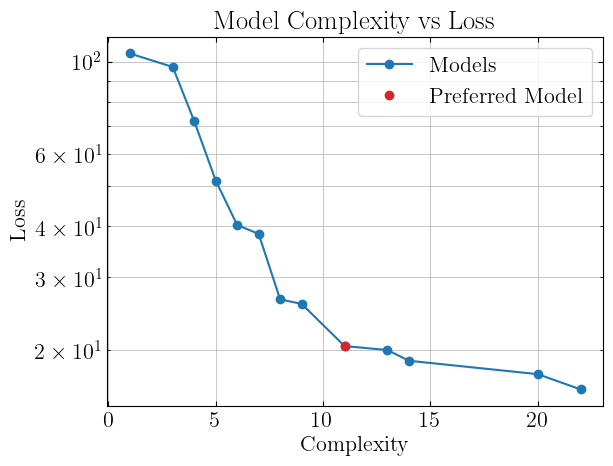

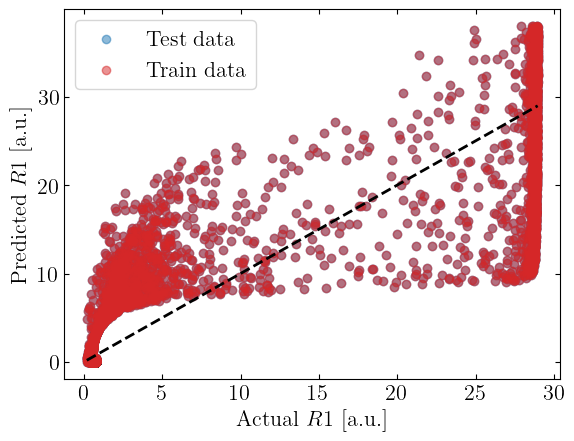

In [13]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_test3...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.735352
Equation: 9.446543

Model 1: Complexity=3, Loss=13.298632
Equation: soc - -8.923039

Model 2: Complexity=4, Loss=9.362926
Equation: exp(soc) * 5.437145

Model 3: Complexity=5, Loss=6.883357
Equation: cube(sqrt(soc) + 1.4188625)

Model 4: Complexity=6, Loss=6.6020975
Equation: cube(soc + -2.0797753) + 13.509433

Model 5: Complexity=7, Loss=3.0043685
Equation: soc * ((soc * -29.06837) + 38.31489)

Model 6: Complexity=9, Loss=2.8922336
Equation: (soc * ((soc * -31.8368) + 41.105026)) - C

Model 7: Complexity=10, Loss=2.3512137
Equation: (soc * exp((soc * -1.6421646) - -4.1395273)) + -2.0008774

Model 8: Complexity=12, Loss=2.2076616
Equation: ((exp((soc * -1.6441802) - -4.1226034) * soc) - C) + -1.2887295

Model 9: Complexity=14, Loss=2.1986675
Equation: (((exp((soc * -1.6592637) - -4.1536765) * soc) + -0.0347788) - C) + -1.4827983

Model 10: Complexity=16, Loss=2.1731434
Equation: (cube(square(soc)) - 1.4512826) + ((soc * exp((-1.6684654 * soc) - -4.

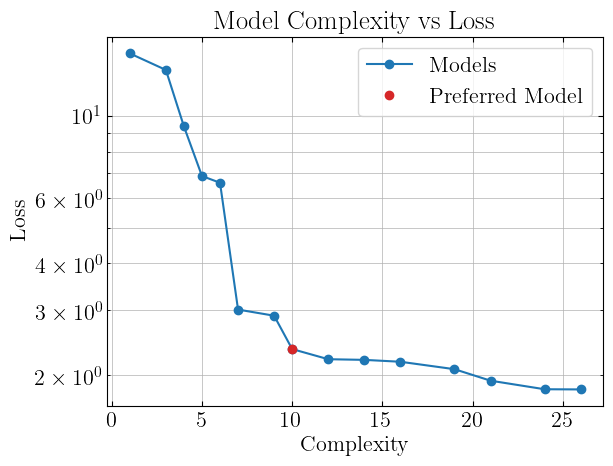

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: soc*exp(soc*(-1.6421646) - 1*(-4.1395273)) - 2.0008774
Loss: 2.3512137
Best model complexity: 10


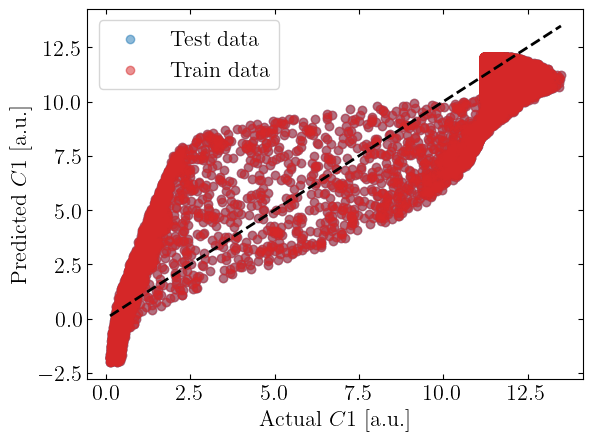

In [14]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_test3...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.14242895
Equation: 2.887312

Model 1: Complexity=3, Loss=0.015178814
Equation: d + 2.3873215

Model 2: Complexity=4, Loss=0.014995216
Equation: square(d) + 2.550785

Model 3: Complexity=5, Loss=0.009399187
Equation: (d * 1.2653561) + 2.2551274

Model 4: Complexity=6, Loss=0.007915721
Equation: (2.2764738 ^ d) + 1.3377204

Model 5: Complexity=8, Loss=0.0078327935
Equation: (0.7012385 ^ soc) + (d + 1.5482993)

Model 6: Complexity=11, Loss=0.0023218968
Equation: (d + 2.2507532) + (((soc + -1.028687) * d) * -0.51710004)

Model 7: Complexity=12, Loss=0.001991543
Equation: (0.6945459 ^ soc) + ((-1.8708907 / (d + -1.8024893)) + 0.5364647)

Model 8: Complexity=15, Loss=0.0018172112
Equation: ((0.49641365 ^ soc) ^ 0.5650547) + ((-2.101822 / (d + -1.8757738)) + 0.46797907)

Model 9: Complexity=17, Loss=0.0004099893
Equation: (sqrt(exp(0.6005378 ^ soc)) - -1.8783735) + (cube(sqrt(d)) - (0.7576572 ^ d))

Model 10: Complexity=18, Loss=0.00036411078
Equation: cube(sqrt(

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -0.7576572**d + d**(3/2) + sqrt(exp(0.6005378**soc)) + 1.8783735
Loss: 0.0004099893
Best model complexity: 17


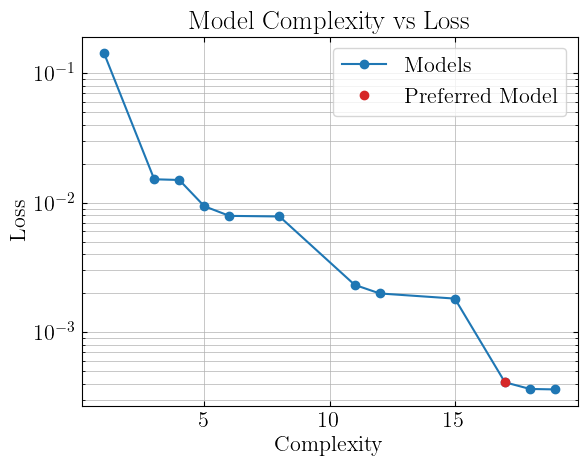

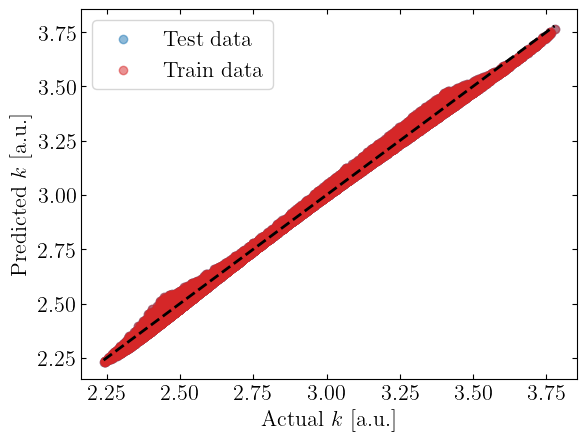

In [15]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(i,d,\mathrm{SOC},s)$

Variable names for element sdot: ['C', 'd', 'soc', 's']
Running symbolic regression for element sdot with run_id sdot_test3...
Settings: iterations=15, populations=30, selection=best


/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0207695
Equation: 0.8759426

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.38254696
Equation: C / 0.3353784

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.1774261
Equation: square(exp(C - d))

Model 5: Complexity=6, Loss=0.06804259
Equation: exp(1.5243889 - d) * C

Model 6: Complexity=9, Loss=0.018373653
Equation: C * ((s + 4.6928387) - (d * 4.4027224))

Model 7: Complexity=13, Loss=0.016267048
Equation: sqrt(C) * exp(C + (0.65492755 + log(1.0732052 - d)))

Model 8: Complexity=14, Loss=0.007314632
Equation: sqrt(exp((cube(-0.30046108 - (d * 1.2195544)) + 3.2738698) - d)) * C

Model 9: Complexity=23, Loss=0.007076367
Equation: C * exp(((0.4569938 - (d * d)) + log(((0.13576995 - square(d)) - (d / 0.8362598)) + 2.945131)) * 1.0219438)

Model 10: Complexity=25, Loss=0.007022019
Equation: (C * 0.9436186) * exp(((log((3.0143466 - (d * square(d))) - (d / 0.69323665)) + 0.08534262

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 5.13939259343144*C*sqrt(exp(-d + (-1.2195544*d - 0.30046108)**3))
Loss: 0.007314632
Best model complexity: 14


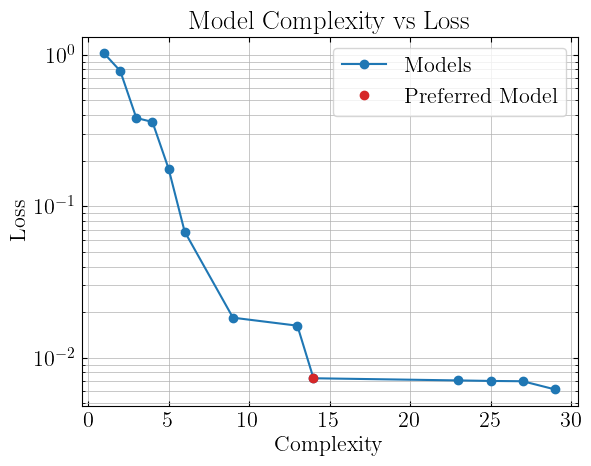

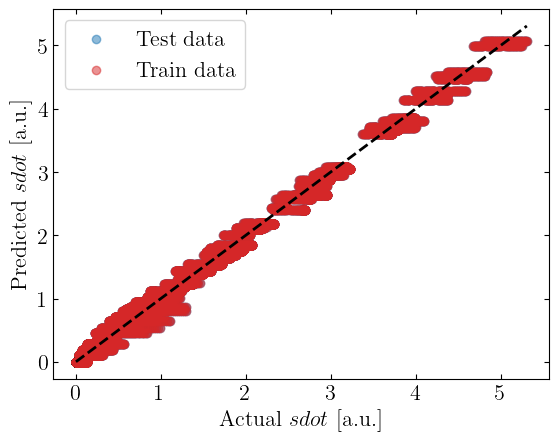

In [16]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f'sdot_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'sdot')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('sdot',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

## Save the models

In [17]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [18]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_s, f'sdot_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_s.get_best(), f'sdot_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}', run_id = RUN_ID)